### logistic_regression

In this notebook, we attempt to predict nomination-worthy novels using a logistic classifier.

In [161]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [162]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [322]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

def bool_to_integer(x):
    return x.astype(int)


# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(bool_to_integer, feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])
            ],
)

# a logistic regressor cannot handle NaNs, so we fill with dummy values.
books_tt['years_since_last_nomination'] = books_tt['years_since_last_nomination'].fillna(99)
books_tt['month_of_publication'] = books_tt['month_of_publication'].fillna('Unknown')

We shall use **walk-forward nested time series cross-validation**.

In [323]:
from walkforward_cv import walk_forward

windows = walk_forward(books_tt)


In [324]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('lr', LogisticRegression(l1_ratio=0, class_weight='balanced', max_iter=1000))
])

books_tt['years_since_last_nomination'] = books_tt['years_since_last_nomination'].fillna(99)
books_tt['month_of_publication'] = books_tt['month_of_publication'].fillna('Unknown')

In [325]:
cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()

    year = book_val['release_year'].mode().values

    model.fit(book_train[features], book_train['target'])

    scores = model.predict_proba(book_val[features])[:, 1]

    ypred = (scores > 0.5).astype(int)

    book_val['predicted'] = ypred

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year, 'f1_score': f1score, 'recall': recall, 'precision': precision})


In [326]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.2911034509013942
STD of f1 score across folds:  0.0656618477631248


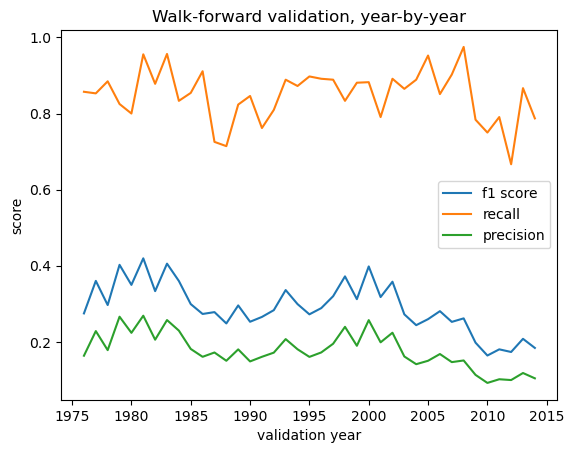

In [327]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

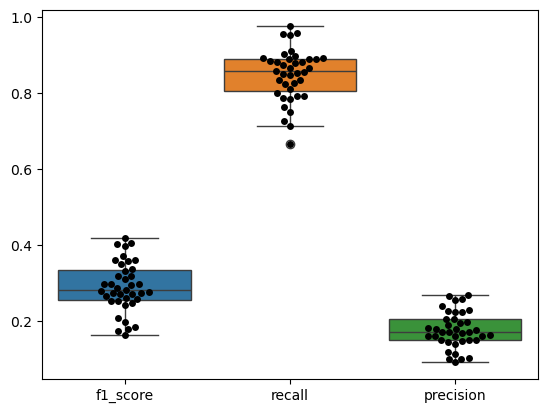

In [328]:
import seaborn as sns

ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])
sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')


Let us look at the most important features.

In [329]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

coefs = model.named_steps['lr'].coef_[0] 

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefs),
    'Net coeff': coefs
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                       Feature  Importance  Net coeff
66          tag_similarity__cohort_similiarity   10.844893 -10.844893
67  nominee_similarity__past_winner_similarity    9.486705   9.486705
18       onehot__first_publisher_bantamspectra    3.105995   3.105995
62                 onehot__first_publisher_tor    2.966762   2.966762
64   onehot__first_publisher_wizardsofthecoast    2.686442  -2.686442
21        onehot__first_publisher_blacklibrary    2.679380  -2.679380
31            onehot__first_publisher_gollancz    2.631577   2.631577
63                 onehot__first_publisher_tsr    2.524633  -2.524633
44               onehot__first_publisher_orbit    2.474870   2.474870
65          onehot__first_publisher_zebrabooks    2.448807  -2.448807
49              onehot__first_publisher_puffin    2.436506  -2.436506
11          onehot__first_publisher_angryrobot    2.389107   2.389107
46       onehot__first_publisher_pinnaclebooks    2.317155  -2.317155
40        onehot__fi

This is very different from the XGB scaler! It does not seem to rely a lot on total past awards etc, but more on cohort similarity and past winner similarity. Notably, the cohort similarity coefficient is negative, ie. being more similar is a disadvantage, whereas the past_winner_similarity is a positive factor.

Let's try to do a grid search to maximize average precision score.

In [330]:
from sklearn.model_selection import RandomizedSearchCV
import scipy as sp

param_search = {
    'lr__C': sp.stats.loguniform(1e-3, 1e2),
    'lr__l1_ratio': [0, 1],
    'lr__solver': ['liblinear'],
    'lr__class_weight': ['balanced', None],
}

# we have our folds earlier, just need to turn them to cv form 
# which wants indices. reuse walkforward function but this time with indices

cv_splits = []
years = np.sort(books_tt['release_year'].unique())

num_years = len(years)
step = 1
initial_size = 5

for i in range(initial_size, num_years - step + 1):
    data_start = 0
    data_end = i
    val_start = data_end
    val_end = val_start + step


    train_years = years[data_start:data_end]
    val_years = years[val_start:val_end]

    window_idx = books_tt.index[books_tt['release_year'].isin(train_years)].to_numpy()
    val_idx = books_tt.index[books_tt['release_year'].isin(val_years)].to_numpy()

    cv_splits.append((window_idx, val_idx))

search = RandomizedSearchCV(
    model,
    param_distributions=param_search,
    n_iter=30,
    cv=cv_splits,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=2
)


In [331]:
search.fit(books_tt[features], books_tt['target'])

Fitting 39 folds for each of 30 candidates, totalling 1170 fits
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.3s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.2s
[CV] END lr__C=0.0745934328572655, lr__class_weight=balanced, lr__l1_ratio=0, lr__solver=liblinear; tot

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.5s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.6s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.7s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.7s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.8s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   0.9s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   1.2s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=None, lr__l1_ratio=0, lr__solver=liblinear; total time=   1.4s
[CV] END lr__C=0.0014857392806279248, lr__class_weight=N

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'lr__C': <scipy.stats....t 0x354e87110>, 'lr__class_weight': ['balanced', None], 'lr__l1_ratio': [0, 1], 'lr__solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can 

In [332]:
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

Best params: {'lr__C': np.float64(1.0129197956845732), 'lr__class_weight': None, 'lr__l1_ratio': 0, 'lr__solver': 'liblinear'}
Best CV score: 0.45531245475656884


In [333]:
results = pd.DataFrame(search.cv_results_)
results = results.sort_values('rank_test_score')
cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
results[cols].head()


,rank_test_score,mean_test_score,std_test_score,params
4,1,0.455312,0.092708,"{'lr__C': 1.0129197956845732, 'lr__class_weigh..."
27,2,0.455046,0.092257,"{'lr__C': 0.9761125443110458, 'lr__class_weigh..."
24,3,0.453879,0.092325,"{'lr__C': 0.5414413211338525, 'lr__class_weigh..."
10,4,0.451888,0.089776,"{'lr__C': 1.1462107403425035, 'lr__class_weigh..."
6,5,0.450612,0.088903,"{'lr__C': 14.528246637516036, 'lr__class_weigh..."


In [334]:
results = results.sort_values('std_test_score')
cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
results[cols].head()


,rank_test_score,mean_test_score,std_test_score,params
21,29,0.363998,0.081819,"{'lr__C': 0.0014857392806279248, 'lr__class_we..."
29,28,0.365925,0.082324,"{'lr__C': 0.0016832027985721903, 'lr__class_we..."
3,27,0.368744,0.083515,"{'lr__C': 0.0019517224641449498, 'lr__class_we..."
16,26,0.370797,0.083760,"{'lr__C': 0.0021147447960615704, 'lr__class_we..."
19,19,0.429428,0.085306,"{'lr__C': 2.6373339933815254, 'lr__class_weigh..."


Let's try that best model with the best pr_auc and try and find the best threshold to maximize f1 score.

In [335]:
model = Pipeline([
    ('preprocess', feature_preprocessing),
    ('lr', LogisticRegression(l1_ratio=0, class_weight=None, max_iter=1000, solver= 'liblinear', C=search.best_params_['lr__C']))
])


from sklearn.model_selection import TunedThresholdClassifierCV

cv_splits = []
years = np.sort(books_tt['release_year'].unique())

num_years = len(years)
step = 1
initial_size = 5

for i in range(initial_size, num_years - step + 1):
    data_start = 0
    data_end = i
    val_start = data_end
    val_end = val_start + step


    train_years = years[data_start:data_end]
    val_years = years[val_start:val_end]

    window_idx = books_tt.index[books_tt['release_year'].isin(train_years)].to_numpy()
    val_idx = books_tt.index[books_tt['release_year'].isin(val_years)].to_numpy()

    cv_splits.append((window_idx, val_idx))

threshold_search = TunedThresholdClassifierCV(
    estimator=search.best_estimator_,
    scoring='f1',
    cv=cv_splits,
    thresholds=100,
    n_jobs=-1,
    store_cv_results=True,
)

threshold_search.fit(books_tt[features], books_tt['target'])


,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...liblinear'))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'f1'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).","[(array([ 0, ...shape=(2324,)), ...), (array([ 0, ...shape=(2937,)), ...), ...]"
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untr

In [336]:
thresholds = threshold_search.cv_results_['thresholds']
scores = threshold_search.cv_results_['scores']

weighted_mean_threshold = np.average(thresholds, weights=scores)
print(weighted_mean_threshold)

0.4113891139214458


Let's take a look at this model.

In [346]:
cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()

    year = book_val['release_year'].mode().values

    scores = threshold_search.predict_proba(book_val[features])[:, 1]

    ypred = (scores > weighted_mean_threshold).astype(int)

    book_val['predicted'] = ypred

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year, 'f1_score': f1score, 'recall': recall, 'precision': precision, 'pr_auc': pr_auc})

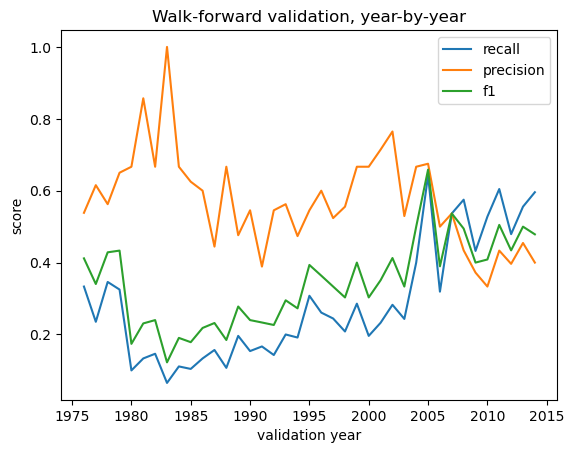

In [347]:
cv_result = pd.DataFrame(cv_data)
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

There seems to be a trend that later years have less precision, but better recall and f1 overall. How different would the tuned threshold be, if we only looked at the year 2005 and onward, considering that our test set is 2015 onwards? Let's try.

In [348]:
threshold_search_2000s = TunedThresholdClassifierCV(
    estimator=search.best_estimator_,
    scoring='f1',
    cv=cv_splits[29:],
    thresholds=100,
    n_jobs=-1,
    store_cv_results=True,
)

threshold_search_2000s.fit(books_tt[features], books_tt['target'])


,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...liblinear'))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'f1'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).","[(array([ 0,...hape=(33691,)), ...), (array([ 0,...hape=(36259,)), ...), ...]"
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untran

In [349]:
thresholds = threshold_search_2000s.cv_results_['thresholds']
scores = threshold_search_2000s.cv_results_['scores']

weighted_mean_threshold_2000s = np.average(thresholds, weights=scores)
print(weighted_mean_threshold_2000s)

0.4873967652349517


This is a bit different. We should compare the two models and see the difference.

In [350]:
book_val = windows[-1][1]

probas = threshold_search.predict_proba(book_val[features])[:, 1]
ypred = (probas > weighted_mean_threshold).astype(int)
ypred_2000s = (probas > weighted_mean_threshold_2000s).astype(int)

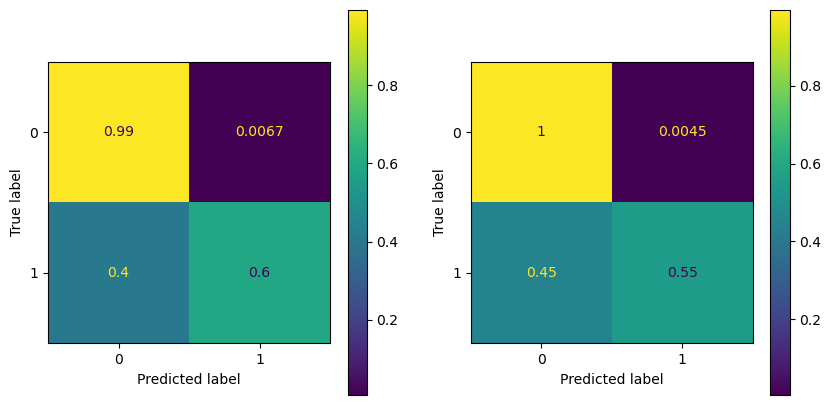

In [351]:
conf = confusion_matrix(book_val['target'], ypred, normalize='true')#.ravel().tolist()
conf2= confusion_matrix(book_val['target'], ypred_2000s, normalize='true')#.ravel().tolist()

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ConfusionMatrixDisplay(confusion_matrix=conf).plot(ax=ax[0])
ConfusionMatrixDisplay(confusion_matrix=conf2).plot(ax=ax[1])


Slight difference in how it does on the validation year, a tradeoff between recall and precision. This tradeoff is small enough that it is still within the fluctuations seen in the validation results year-by-year. Let us keep the threshold which has been averaged over more folds.

In [352]:
# we export the model using joblib. let us
import joblib

export_path = 'trained_models/'

joblib.dump(threshold_search, export_path + "logistic_model.pkl") 

['trained_models/logistic_model.pkl']